# HIE

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import MCI; import random
from sklearn.preprocessing import StandardScaler

illinois = pd.read_csv('data/data_rec.csv',index_col=0)
# Find non-binary columns
non_binary_cols = [col for col in illinois.columns if illinois[col].nunique() > 2 and illinois[col].dtype != 'object' and col!='time_r']
# Standardize the non-binary columns
scaler = StandardScaler()
illinois[non_binary_cols] = scaler.fit_transform(illinois[non_binary_cols])
illinois = pd.get_dummies(illinois,drop_first=True)*1
data = illinois.rename(columns={'Z_HIE': 'Z','A_HIE': 'A','time_r': 'time', 'status_r': 'status'}).loc[illinois['Z_JSIE']==0,:].drop(columns=['A_JSIE','Z_JSIE'])
data = data.reset_index().drop(columns=['index'])

covariates = [
    # demographics
    "AGE","MALE",   
    "RACE_Hispanic","RACE_NativeAmerican","RACE_Other","RACE_White",
    "CLAIMDT",
    # historical earnings
    "AVPREARN","PREPEARN",
    # "L1QWAGES","L2QWAGES","L3QWAGES","L4QWAGES",
]
print(data.columns)

Index(['AGE', 'AVPREARN', 'BONELIGB', 'CLAIMDT', 'DEPALLOW', 'ELIG2',
       'L1QWAGES', 'L2QWAGES', 'L3QWAGES', 'L4QWAGES', 'MALE', 'MBASR',
       'NOHSUB', 'NOHSUB1', 'POSPEARN', 'POSQEARN', 'PREPEARN', 'SRBEN1',
       'SRBENYR', 'WGETOT1', 'WGETOT2', 'WGETOT3', 'WGETOT4', 'WGETOT5',
       'WGETOT6', 'Z', 'A', 'time', 'status', 'RACE_Hispanic',
       'RACE_NativeAmerican', 'RACE_Other', 'RACE_White'],
      dtype='object')


In [2]:

np.random.seed(2025); random.seed(2025)
model = MCI.train_nuisance_func(
    data,Kfold=5,tau=182,accuracy=200,min_val=1e-2,
    method_SD=['rsf', covariates+['Z','A'],200,10],
    method_SC=['rsf', covariates+['Z','A'],100,10],
    method_pi=['rf', covariates,200,10],
    method_f=['rf', covariates,200,10]
)

fit_MCI2 = MCI.Marginal_Cox_Instrumental2(data, model) 
fit_MCI = MCI.Marginal_Cox_Instrumental(data, model)

import pickle
with open('data/fit_MCI2_HIE.pkl', 'wb') as f:
    pickle.dump(fit_MCI2, f)
with open('data/fit_MCI_HIE.pkl', 'wb') as f:
    pickle.dump(fit_MCI, f)

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed:   38.1s remaining:   57.1s
[Parallel(n_jobs=5)]: Done   3 out of   5 | elapsed:   38.9s remaining:   25.9s
[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed:   50.0s finished
/mnt/share_data/CSY/MSM_COX_py/real_data/MCI.py:527: RuntimeWarning: invalid value encountered in divide
  par_ipw  = np.log(G_ipw_up.mean(axis=0)/G_ipw_low.mean(axis=0)); par_ipw = replace_na_nearest(par_ipw)
/mnt/share_data/CSY/MSM_COX_py/real_data/MCI.py:530: RuntimeWarning: invalid value encountered in divide
  std_ipw2 = np.sqrt(((W_ipw1+W_ipw2-(W_ipw3 + W_ipw4)*np.exp(-par_ipw))**2).mean(axis=0)/(G_ipw_low.mean(axis=0)**2)/n)
/mnt/share_data/CSY/MSM_COX_py/real_data/MCI.py:379: RuntimeWarning: divide by zero encountered in log
  par_aug = np.log((R10_avg[0] - R10_avg) / G_aug.mean(axis=0))
/mnt/share_data/CSY/MSM_COX_py/real_data/MCI.py:379: RuntimeWarning: invalid value encounter

# JSIE

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import MCI; import random
from sklearn.preprocessing import StandardScaler

np.random.seed(2025); random.seed(2025)
illinois = pd.read_csv('data/data_rec.csv',index_col=0)
# Find non-binary columns
non_binary_cols = [col for col in illinois.columns if illinois[col].nunique() > 2 and illinois[col].dtype != 'object' and col!='time_r']
# Standardize non-binary columns
scaler = StandardScaler()
illinois[non_binary_cols] = scaler.fit_transform(illinois[non_binary_cols])
illinois = pd.get_dummies(illinois,drop_first=True)*1
data = illinois.rename(columns={'Z_JSIE': 'Z','A_JSIE': 'A','time_r': 'time', 'status_r': 'status'}).loc[illinois['Z_HIE']==0,:].drop(columns=['A_HIE','Z_HIE'])
data = data.reset_index().drop(columns=['index'])

covariates = [
    # demographics
    "AGE","MALE",   
    "RACE_Hispanic","RACE_NativeAmerican","RACE_Other","RACE_White",
    "CLAIMDT",
    # historical earnings
    "AVPREARN","PREPEARN",
    # "L1QWAGES","L2QWAGES","L3QWAGES","L4QWAGES",
]


model = MCI.train_nuisance_func(
    data,Kfold=5,tau=182,accuracy=200,min_val=1e-2,
    method_SD=['rsf', covariates+['Z','A'],200,10],
    method_SC=['rsf', covariates+['Z','A'],100,10],
    method_pi=['rf', covariates,200,10],
    method_f=['rf', covariates,200,10]
)

fit_MCI2 = MCI.Marginal_Cox_Instrumental2(data, model) 
fit_MCI = MCI.Marginal_Cox_Instrumental(data, model)

import pickle
with open('data/fit_MCI2_JSIE.pkl', 'wb') as f:
    pickle.dump(fit_MCI2, f)
with open('data/fit_MCI_JSIE.pkl', 'wb') as f:
    pickle.dump(fit_MCI, f)
print('finished', flush=True)





[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed:   33.7s remaining:   50.5s
[Parallel(n_jobs=5)]: Done   3 out of   5 | elapsed:   34.5s remaining:   23.0s
[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed:   44.5s finished
/mnt/share_data/CSY/MSM_COX_py/real_data/MCI.py:524: RuntimeWarning: invalid value encountered in log
  par_aug  = np.log(G_aug_up.mean(axis=0)/G_aug_low.mean(axis=0));
/mnt/share_data/CSY/MSM_COX_py/real_data/MCI.py:527: RuntimeWarning: invalid value encountered in divide
  par_ipw  = np.log(G_ipw_up.mean(axis=0)/G_ipw_low.mean(axis=0)); par_ipw = replace_na_nearest(par_ipw)
/mnt/share_data/CSY/MSM_COX_py/real_data/MCI.py:530: RuntimeWarning: invalid value encountered in divide
  std_ipw2 = np.sqrt(((W_ipw1+W_ipw2-(W_ipw3 + W_ipw4)*np.exp(-par_ipw))**2).mean(axis=0)/(G_ipw_low.mean(axis=0)**2)/n)


finished


/mnt/share_data/CSY/MSM_COX_py/real_data/MCI.py:379: RuntimeWarning: divide by zero encountered in log
  par_aug = np.log((R10_avg[0] - R10_avg) / G_aug.mean(axis=0))
/mnt/share_data/CSY/MSM_COX_py/real_data/MCI.py:380: RuntimeWarning: divide by zero encountered in log
  par_or = np.log((or1_avg[0] - or1_avg) / G_or.mean(axis=0))
/mnt/share_data/CSY/MSM_COX_py/real_data/MCI.py:381: RuntimeWarning: invalid value encountered in divide
  par_ipw = np.log((ipw10_avg[0] - ipw10_avg) / G_ipw.mean(axis=0))
/mnt/share_data/CSY/MSM_COX_py/real_data/MCI.py:381: RuntimeWarning: divide by zero encountered in log
  par_ipw = np.log((ipw10_avg[0] - ipw10_avg) / G_ipw.mean(axis=0))
/mnt/share_data/CSY/MSM_COX_py/real_data/MCI.py:390: RuntimeWarning: invalid value encountered in divide
  std_aug2 = np.sqrt(W_aug.var(axis=0) / G_aug.mean(axis=0)**2 / n)
/mnt/share_data/CSY/MSM_COX_py/real_data/MCI.py:391: RuntimeWarning: invalid value encountered in divide
  std_or2  = np.sqrt(W_or.var(axis=0) / G_or.m

# Plot

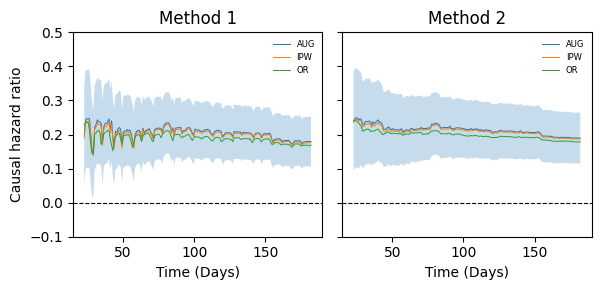

In [4]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open('data/fit_MCI2_JSIE.pkl', 'rb') as f:
    fit_MCI2 = pickle.load(f)

with open('data/fit_MCI_JSIE.pkl', 'rb') as f:
    fit_MCI = pickle.load(f)

# Method 1
curve1 = np.array(fit_MCI['curve_hazard']['par_aug'][25:])
se1 = np.array(fit_MCI['curve_hazard']['std_aug'][25:])

curve1_IPW = np.array(fit_MCI['curve_hazard']['par_ipw'][25:])
curve1_OR  = np.array(fit_MCI['curve_hazard']['par_or'][25:])

# Method 2
curve2 = np.array(fit_MCI2['curve_hazard']['par_aug'][25:])
se2 = np.array(fit_MCI2['curve_hazard']['std_aug'][25:])

curve2_IPW = np.array(fit_MCI2['curve_hazard']['par_ipw'][25:])
curve2_OR  = np.array(fit_MCI2['curve_hazard']['par_or'][25:])

t = np.array(fit_MCI2['curve_hazard']['target_time'][25:])

fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=True)

# ---------------- Method 1 ----------------
ax = axes[0]

ax.plot(t, curve1, label='AUG', linewidth=0.7)
ax.fill_between(
    t,
    curve1 - 1.96 * se1,
    curve1 + 1.96 * se1,
    alpha=0.25
)

ax.plot(t, curve1_IPW, label='IPW', linewidth=0.7)
ax.plot(t, curve1_OR, label='OR', linewidth=0.7)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Method 1')
ax.set_xlabel('Time (Days)')
ax.set_ylabel('Causal hazard ratio')
ax.legend(fontsize=6, loc='best', frameon=False)

# ---------------- Method 2 ----------------
ax = axes[1]

ax.plot(t, curve2, label='AUG', linewidth=0.7)
ax.fill_between(
    t,
    curve2 - 1.96 * se2,
    curve2 + 1.96 * se2,
    alpha=0.25
)

ax.plot(t, curve2_IPW, label='IPW', linewidth=0.7)
ax.plot(t, curve2_OR, label='OR', linewidth=0.7)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Method 2')
ax.set_xlabel('Time (Days)')
ax.legend(fontsize=6, loc='best', frameon=False)

plt.tight_layout();plt.ylim(-0.1,0.5)
plt.savefig('data/JSIE_two_methods.pdf', bbox_inches='tight')
plt.show()

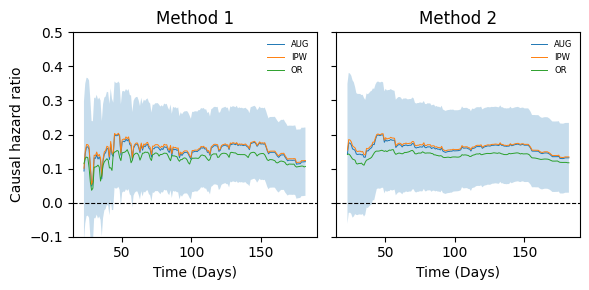

In [5]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open('data/fit_MCI2_HIE.pkl', 'rb') as f:
    fit_MCI2 = pickle.load(f)

with open('data/fit_MCI_HIE.pkl', 'rb') as f:
    fit_MCI = pickle.load(f)

# Method 1
curve1 = np.array(fit_MCI['curve_hazard']['par_aug'][25:])
se1 = np.array(fit_MCI['curve_hazard']['std_aug'][25:])

curve1_IPW = np.array(fit_MCI['curve_hazard']['par_ipw'][25:])
curve1_OR  = np.array(fit_MCI['curve_hazard']['par_or'][25:])

# Method 2
curve2 = np.array(fit_MCI2['curve_hazard']['par_aug'][25:])
se2 = np.array(fit_MCI2['curve_hazard']['std_aug'][25:])

curve2_IPW = np.array(fit_MCI2['curve_hazard']['par_ipw'][25:])
curve2_OR  = np.array(fit_MCI2['curve_hazard']['par_or'][25:])

t = np.array(fit_MCI2['curve_hazard']['target_time'][25:])

fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=True)

# ---------------- Method 1 ----------------
ax = axes[0]

ax.plot(t, curve1, label='AUG', linewidth=0.7)
ax.fill_between(
    t,
    curve1 - 1.96 * se1,
    curve1 + 1.96 * se1,
    alpha=0.25
)

ax.plot(t, curve1_IPW, label='IPW', linewidth=0.7)
ax.plot(t, curve1_OR, label='OR', linewidth=0.7)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Method 1')
ax.set_xlabel('Time (Days)')
ax.set_ylabel('Causal hazard ratio')
ax.legend(fontsize=6, loc='best', frameon=False)

# ---------------- Method 2 ----------------
ax = axes[1]

ax.plot(t, curve2, label='AUG', linewidth=0.7)
ax.fill_between(
    t,
    curve2 - 1.96 * se2,
    curve2 + 1.96 * se2,
    alpha=0.25
)

ax.plot(t, curve2_IPW, label='IPW', linewidth=0.7)
ax.plot(t, curve2_OR, label='OR', linewidth=0.7)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Method 2')
ax.set_xlabel('Time (Days)')
ax.legend(fontsize=6, loc='best', frameon=False)

plt.tight_layout();plt.ylim(-0.1,0.5)
plt.savefig('data/HIE_two_methods.pdf', bbox_inches='tight')
plt.show()